<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science-Ml/blob/main/PCA_Wine_Clustering_Assignment%5B16%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA and K-Means Clustering – Wine Dataset

The workflow covers:
1. Exploratory Data Analysis
2. Standardization and PCA
3. Choosing the number of principal components using scree plot and cumulative explained variance
4. K-Means clustering on the original standardized dataset
5. K-Means clustering on PCA-transformed data
6. Visualization and clustering evaluation
7. Comparison and analysis
8. Conclusion and practical recommendations

Standardize the features before PCA, apply clustering to the original data and PCA data, compare the results, and discuss the trade-offs.

## 1. Load the Dataset and Basic Exploration

The supplied `wine.csv` file contains 178 observations and 14 columns.

`Type` is treated as a **class label/reference column**, not as an input feature for unsupervised PCA or K-Means. The remaining 13 columns are the wine measurements used for dimensionality reduction and clustering.

This is important because including the class label as a clustering feature would introduce target information into an otherwise unsupervised analysis.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

df = pd.read_csv("wine.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe().T)


Dataset shape: (178, 14)


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Data types:


,Data Type
Type,int64
Alcohol,float64
Malic,float64
Ash,float64
Alcalinity,float64
Magnesium,int64
Phenols,float64
Flavanoids,float64
Nonflavanoids,float64
Proanthocyanins,float64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


## 2. Missing Values, Duplicates and Basic Consistency Checks

I first check whether there are missing observations or duplicate rows. I also check whether the target/reference column contains a reasonable set of class labels.

The PCA and clustering features themselves are numerical, so categorical encoding is not needed for this dataset.

In [3]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})
display(missing)

print("Duplicate rows:", df.duplicated().sum())
print("Unique Type values:", sorted(df["Type"].unique()))
print("\nType distribution:")
display(df["Type"].value_counts().sort_index().to_frame("Count"))


,Missing Count,Missing Percentage
Type,0,0.0
Alcohol,0,0.0
Malic,0,0.0
Ash,0,0.0
Alcalinity,0,0.0
Magnesium,0,0.0
Phenols,0,0.0
Flavanoids,0,0.0
Nonflavanoids,0,0.0
Proanthocyanins,0,0.0


Duplicate rows: 0
Unique Type values: [np.int64(1), np.int64(2), np.int64(3)]

Type distribution:


,Count
Type,
1,59
2,71
3,48


## 3. Feature Distributions

 histograms, box plots, or density plots. I use histograms and box plots to understand the distributions and identify possible extreme observations.

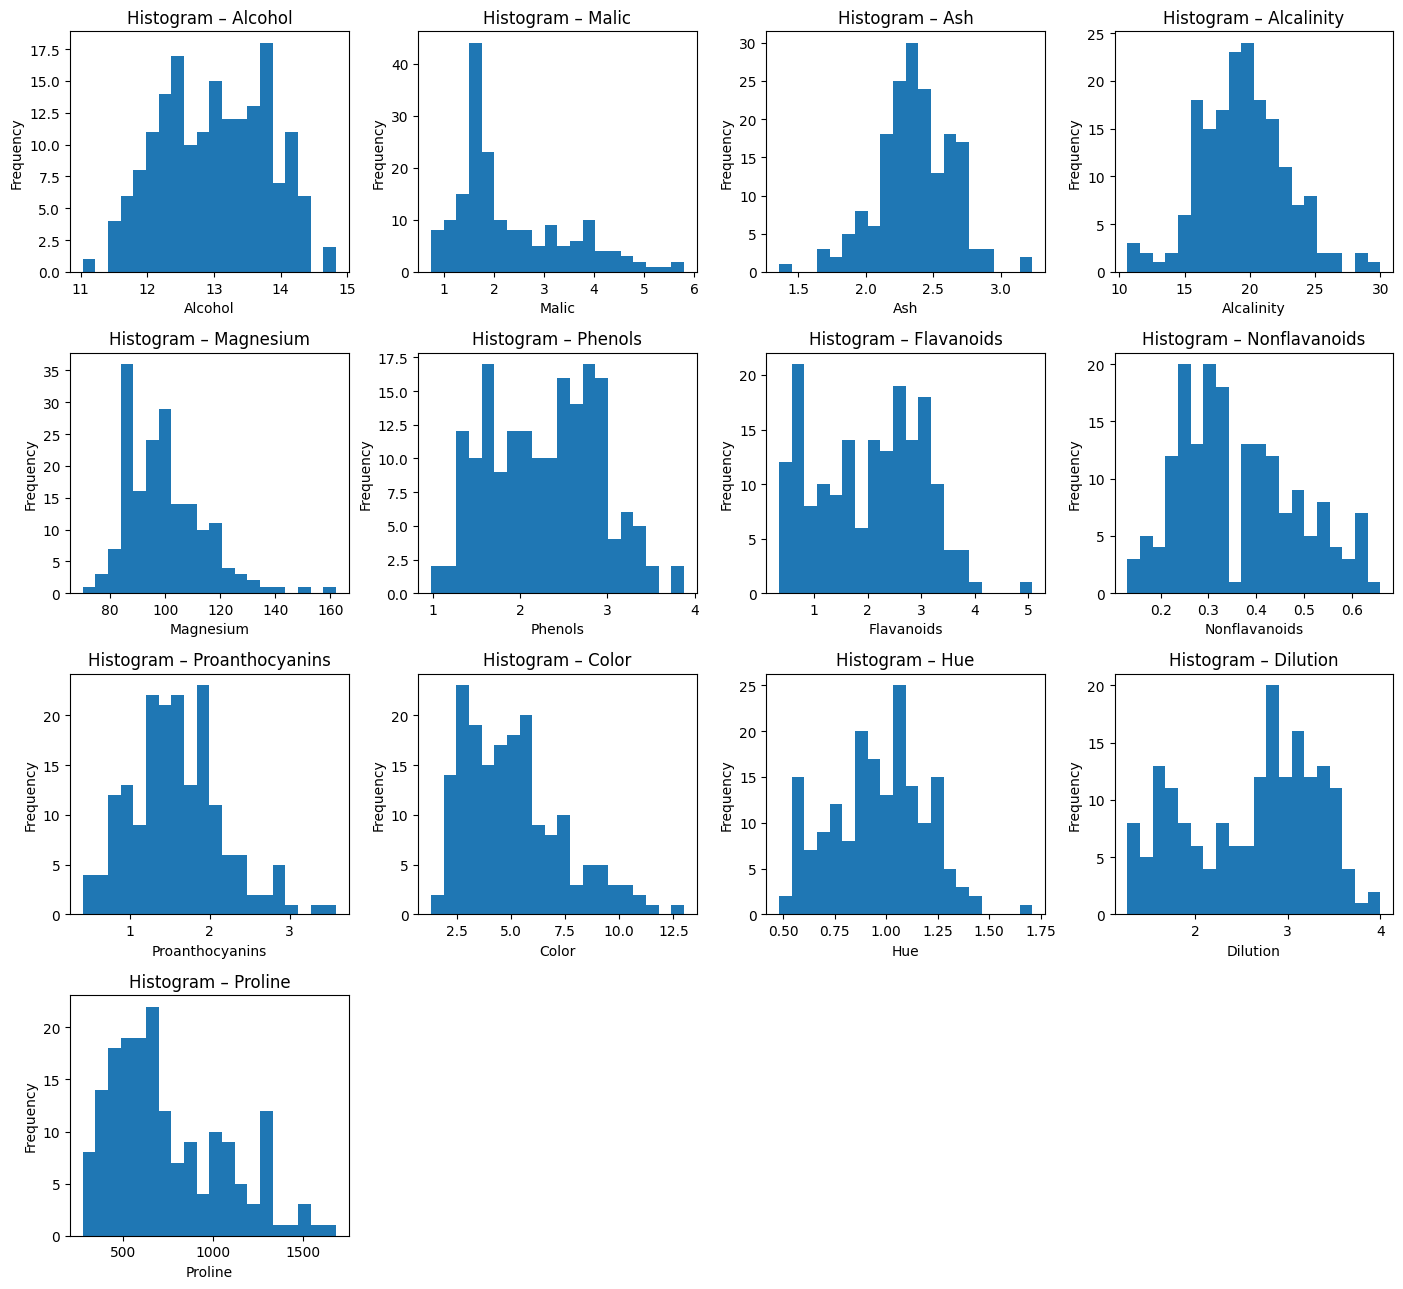

In [4]:
feature_cols = [c for c in df.columns if c != "Type"]

fig, axes = plt.subplots(4, 4, figsize=(14, 13))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=20)
    ax.set_title(f"Histogram – {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


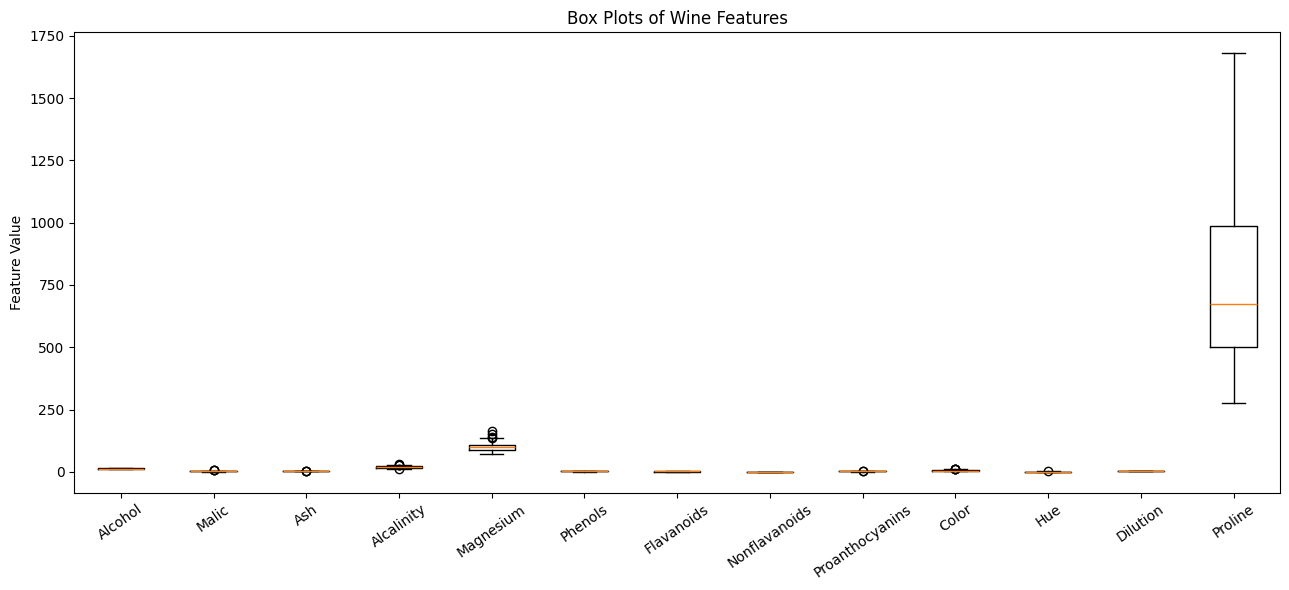

In [5]:
plt.figure(figsize=(13, 6))
plt.boxplot([df[c] for c in feature_cols], labels=feature_cols)
plt.title("Box Plots of Wine Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


### Outlier check using the IQR rule

For each numerical feature I calculate:

- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Values outside these limits are potential outliers. I do not automatically remove them because an unusual wine measurement is not necessarily a data-entry error.

In [6]:
outlier_rows = []

for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": count
    })

display(pd.DataFrame(outlier_rows))


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Alcohol,12.3625,13.6775,1.3150,10.39000,15.65000,0
1,Malic,1.6025,3.0825,1.4800,-0.61750,5.30250,3
2,Ash,2.2100,2.5575,0.3475,1.68875,3.07875,3
3,Alcalinity,17.2000,21.5000,4.3000,10.75000,27.95000,4
4,Magnesium,88.0000,107.0000,19.0000,59.50000,135.50000,4
5,Phenols,1.7425,2.8000,1.0575,0.15625,4.38625,0
6,Flavanoids,1.2050,2.8750,1.6700,-1.30000,5.38000,0
7,Nonflavanoids,0.2700,0.4375,0.1675,0.01875,0.68875,0
8,Proanthocyanins,1.2500,1.9500,0.7000,0.20000,3.00000,2
9,Color,3.2200,6.2000,2.9800,-1.25000,10.67000,4


## 4. Correlation Analysis

The assignment asks to investigate relationships between features. I calculate the correlation matrix before PCA.

Because the variables are measured on very different scales (for example, Proline is much larger numerically than several other measurements), correlation alone is not enough to decide how much influence a feature should have in PCA. This is why standardization is performed before PCA.

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Alcalinity,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Magnesium,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoids,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanthocyanins,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


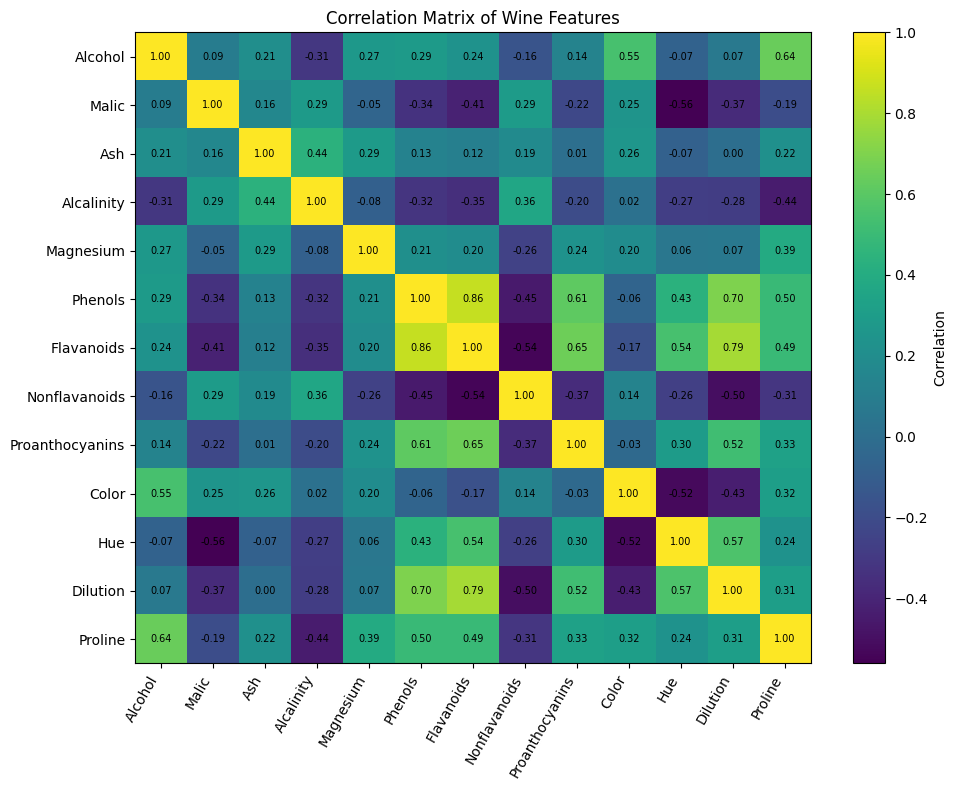

In [7]:
corr = df[feature_cols].corr()

display(corr.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=60, ha="right")
plt.yticks(range(len(feature_cols)), feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix of Wine Features")
plt.tight_layout()
plt.show()


# Task 2 – Dimensionality Reduction with PCA

## 5. Standardize the Features

The assignment requires the features to be standardized before PCA. Standardization transforms each feature approximately to mean 0 and standard deviation 1.

Formula:

**z = (x − μ) / σ**

This is especially important here because the features have very different numerical ranges.

In [8]:
X = df[feature_cols].copy()
y_reference = df["Type"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("Means after standardization:")
display(X_scaled_df.mean().round(6).to_frame("Mean"))

print("Standard deviations after standardization:")
display(X_scaled_df.std(ddof=0).round(6).to_frame("Std"))


Means after standardization:


,Mean
Alcohol,-0.0
Malic,-0.0
Ash,-0.0
Alcalinity,-0.0
Magnesium,-0.0
Phenols,0.0
Flavanoids,-0.0
Nonflavanoids,0.0
Proanthocyanins,-0.0
Color,0.0


Standard deviations after standardization:


,Std
Alcohol,1.0
Malic,1.0
Ash,1.0
Alcalinity,1.0
Magnesium,1.0
Phenols,1.0
Flavanoids,1.0
Nonflavanoids,1.0
Proanthocyanins,1.0
Color,1.0


## 6. Implement PCA

I first fit PCA with all available components. This allows me to inspect the variance explained by every principal component before deciding how many components to keep.

In [9]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Principal Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(pca_summary.round(4))


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.3620,0.3620
1,2,0.1921,0.5541
2,3,0.1112,0.6653
3,4,0.0707,0.7360
4,5,0.0656,0.8016
5,6,0.0494,0.8510
6,7,0.0424,0.8934
7,8,0.0268,0.9202
8,9,0.0222,0.9424
9,10,0.0193,0.9617


## 7. Scree Plot and Cumulative Explained Variance

The scree plot shows how much variance each component explains.

The cumulative explained-variance curve helps choose a smaller number of components while retaining most of the information in the standardized dataset.

For this notebook, I select the smallest number of components that reaches **approximately 90% cumulative explained variance**. This is a practical threshold for reducing dimensionality while retaining most of the variance; the exact cumulative values are shown in the table and plot.

Components needed for at least 90% explained variance: 8
Cumulative explained variance at that point: 0.9202


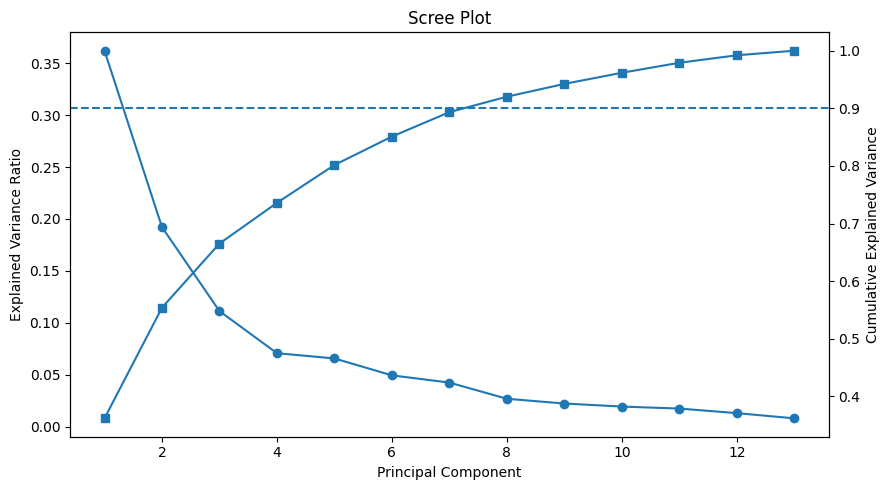

In [10]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components needed for at least 90% explained variance:", n_components_90)
print("Cumulative explained variance at that point:",
      round(cumulative_variance[n_components_90 - 1], 4))

fig, ax1 = plt.subplots(figsize=(9, 5))
components = np.arange(1, len(explained_variance) + 1)

ax1.plot(components, explained_variance, marker="o")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("Scree Plot")

ax2 = ax1.twinx()
ax2.plot(components, cumulative_variance, marker="s")
ax2.axhline(0.90, linestyle="--")
ax2.set_ylabel("Cumulative Explained Variance")

plt.tight_layout()
plt.show()


## 8. Transform the Dataset into Principal Components

After deciding the number of components, I fit PCA again using that number and transform the standardized dataset.

In [11]:
pca = PCA(n_components=n_components_90)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i}" for i in range(1, n_components_90 + 1)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

print("PCA-transformed shape:", X_pca_df.shape)
display(X_pca_df.head())

print("\nExplained variance by retained components:")
display(pd.DataFrame({
    "Component": pca_columns,
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
}).round(4))


PCA-transformed shape: (178, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700



Explained variance by retained components:


,Component,Explained Variance,Cumulative Variance
0,PC1,0.3620,0.3620
1,PC2,0.1921,0.5541
2,PC3,0.1112,0.6653
3,PC4,0.0707,0.7360
4,PC5,0.0656,0.8016
5,PC6,0.0494,0.8510
6,PC7,0.0424,0.8934
7,PC8,0.0268,0.9202


## 9. PCA Component Loadings

The PCA loadings show how strongly each original feature contributes to each principal component.

A larger absolute loading means that the original feature has a stronger contribution to that component. The sign indicates the direction of the relationship with the component.

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=pca_columns
)

display(loadings.round(3))


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Alcohol,0.144,0.484,-0.207,-0.018,-0.266,0.214,-0.056,0.396
Malic,-0.245,0.225,0.089,0.537,0.035,0.537,0.421,0.066
Ash,-0.002,0.316,0.626,-0.214,-0.143,0.154,-0.149,-0.170
Alcalinity,-0.239,-0.011,0.612,0.061,0.066,-0.101,-0.287,0.428
Magnesium,0.142,0.300,0.131,-0.352,0.727,0.038,0.323,-0.156
Phenols,0.395,0.065,0.146,0.198,-0.149,-0.084,-0.028,-0.406
Flavanoids,0.423,-0.003,0.151,0.152,-0.109,-0.019,-0.061,-0.187
Nonflavanoids,-0.299,0.029,0.170,-0.203,-0.501,-0.259,0.595,-0.233
Proanthocyanins,0.313,0.039,0.149,0.399,0.137,-0.534,0.372,0.368
Color,-0.089,0.530,-0.137,0.066,-0.076,-0.419,-0.228,-0.034


# Task 3 – Clustering with Original Data

## 10. Choosing K for K-Means

The assignment gives K-Means as an example clustering algorithm. I use K-Means.

To make the comparison fair, the "original data" for clustering is the **standardized original feature space**, because the assignment requires standardization for PCA and the raw variables are on very different scales.

I evaluate several K values using the silhouette score. I also calculate the Davies–Bouldin index:

- Higher silhouette score is better.
- Lower Davies–Bouldin index is better.

In [13]:
k_values = range(2, 9)

original_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)

    original_scores.append({
        "K": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels)
    })

original_k_results = pd.DataFrame(original_scores)
display(original_k_results.round(4))


,K,Silhouette,Davies-Bouldin
0,2,0.2593,1.5260
1,3,0.2849,1.3892
2,4,0.2586,1.8170
3,5,0.2315,1.6811
4,6,0.2372,1.5544
5,7,0.2036,1.6606
6,8,0.1570,1.7409


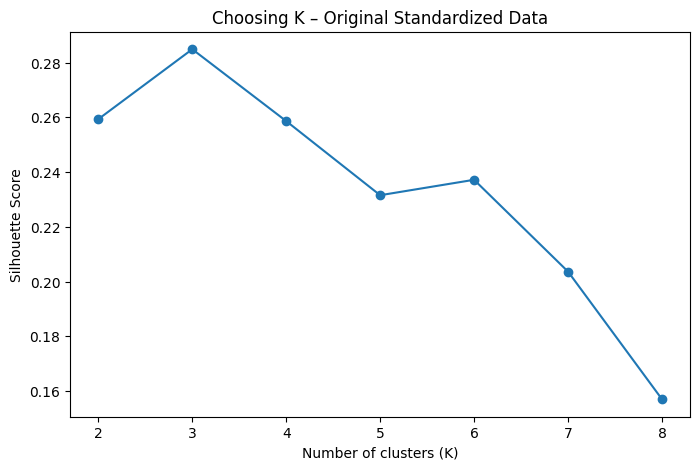

Best K based on silhouette score for original data: 3


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(original_k_results["K"], original_k_results["Silhouette"], marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Choosing K – Original Standardized Data")
plt.show()

best_k_original = int(
    original_k_results.loc[original_k_results["Silhouette"].idxmax(), "K"]
)

print("Best K based on silhouette score for original data:", best_k_original)


## 11. Apply K-Means to the Original Standardized Data

In [15]:
kmeans_original = KMeans(
    n_clusters=best_k_original,
    random_state=42,
    n_init=20
)

labels_original = kmeans_original.fit_predict(X_scaled)

sil_original = silhouette_score(X_scaled, labels_original)
db_original = davies_bouldin_score(X_scaled, labels_original)

print("Original-data clustering results")
print("K =", best_k_original)
print("Silhouette score =", round(sil_original, 4))
print("Davies-Bouldin index =", round(db_original, 4))

display(pd.Series(labels_original).value_counts().sort_index().to_frame("Cluster Size"))


Original-data clustering results
K = 3
Silhouette score = 0.2849
Davies-Bouldin index = 1.3892


,Cluster Size
0,65
1,51
2,62


## 12. Visualize Original-Data Clusters

The original dataset has more than two dimensions, so I use the first two principal components **only for visualization**. The clustering itself was performed in the full standardized feature space.

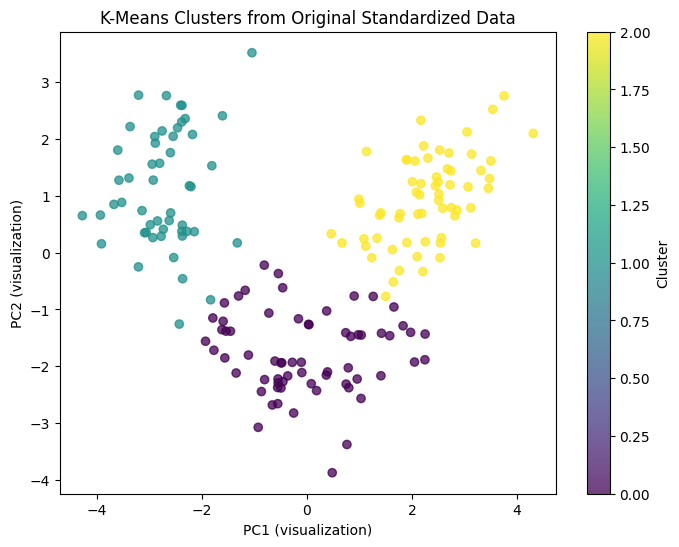

In [16]:
# Visualization only: project standardized data onto the first two PCs.
X_visual_original = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_visual_original[:, 0],
    X_visual_original[:, 1],
    c=labels_original,
    alpha=0.75
)
plt.xlabel("PC1 (visualization)")
plt.ylabel("PC2 (visualization)")
plt.title("K-Means Clusters from Original Standardized Data")
plt.colorbar(label="Cluster")
plt.show()


# Task 4 – Clustering with PCA Data

## 13. Apply K-Means to the PCA-Transformed Dataset

To make the comparison consistent, I test the same range of K values on the PCA-transformed data and choose the K with the highest silhouette score.

,K,Silhouette,Davies-Bouldin
0,2,0.2930,1.3549
1,3,0.3150,1.2669
2,4,0.2846,1.6391
3,5,0.2683,1.5403
4,6,0.2214,1.5813
5,7,0.1904,1.7025
6,8,0.1788,1.5656


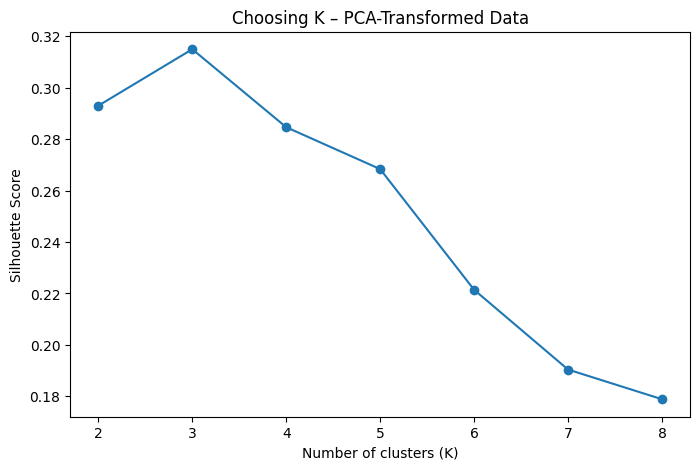

Best K based on silhouette score for PCA data: 3


In [17]:
pca_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)

    pca_scores.append({
        "K": k,
        "Silhouette": silhouette_score(X_pca, labels),
        "Davies-Bouldin": davies_bouldin_score(X_pca, labels)
    })

pca_k_results = pd.DataFrame(pca_scores)
display(pca_k_results.round(4))

plt.figure(figsize=(8, 5))
plt.plot(pca_k_results["K"], pca_k_results["Silhouette"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Choosing K – PCA-Transformed Data")
plt.show()

best_k_pca = int(
    pca_k_results.loc[pca_k_results["Silhouette"].idxmax(), "K"]
)

print("Best K based on silhouette score for PCA data:", best_k_pca)


In [18]:
kmeans_pca = KMeans(
    n_clusters=best_k_pca,
    random_state=42,
    n_init=20
)

labels_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
db_pca = davies_bouldin_score(X_pca, labels_pca)

print("PCA-data clustering results")
print("K =", best_k_pca)
print("Silhouette score =", round(sil_pca, 4))
print("Davies-Bouldin index =", round(db_pca, 4))

display(pd.Series(labels_pca).value_counts().sort_index().to_frame("Cluster Size"))


PCA-data clustering results
K = 3
Silhouette score = 0.315
Davies-Bouldin index = 1.2669


,Cluster Size
0,65
1,51
2,62


## 14. Visualize PCA Clusters

Because PCA provides a lower-dimensional representation, the retained principal components can be plotted directly. If at least two components were retained, PC1 and PC2 provide the main visualization.

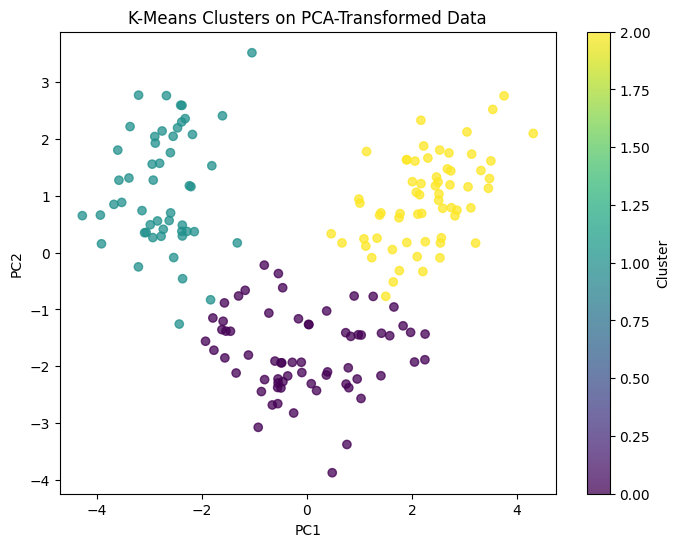

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_pca,
    alpha=0.75
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Transformed Data")
plt.colorbar(label="Cluster")
plt.show()


# Task 5 – Comparison and Analysis

## 15. Compare Clustering Performance

I compare:
- Silhouette score
- Davies–Bouldin index
- Number of clusters
- Cluster sizes

A higher silhouette score indicates better separation and cohesion. A lower Davies–Bouldin value indicates better clustering according to that metric.

In [20]:
comparison = pd.DataFrame([
    {
        "Dataset": "Original standardized data",
        "K": best_k_original,
        "Silhouette Score": sil_original,
        "Davies-Bouldin Index": db_original
    },
    {
        "Dataset": "PCA-transformed data",
        "K": best_k_pca,
        "Silhouette Score": sil_pca,
        "Davies-Bouldin Index": db_pca
    }
])

display(comparison.round(4))

print("Cluster sizes – Original:")
display(pd.Series(labels_original).value_counts().sort_index().to_frame("Count"))

print("Cluster sizes – PCA:")
display(pd.Series(labels_pca).value_counts().sort_index().to_frame("Count"))


,Dataset,K,Silhouette Score,Davies-Bouldin Index
0,Original standardized data,3,0.2849,1.3892
1,PCA-transformed data,3,0.3150,1.2669


Cluster sizes – Original:


,Count
0,65
1,51
2,62


Cluster sizes – PCA:


,Count
0,65
1,51
2,62


## 16. Compare Cluster Assignments

Since the same observations are clustered in both analyses, I calculate the **Adjusted Rand Index (ARI)** between the original-data and PCA-data cluster assignments.

ARI is not a required clustering metric in the assignment, but it is useful here as an additional comparison of whether the two clustering solutions assign observations to similar groups.

I also compare both unsupervised clusterings with the supplied `Type` labels using ARI and NMI. These are **external reference comparisons only**; the target labels were not used to train K-Means.

In [21]:
ari_original_pca = adjusted_rand_score(labels_original, labels_pca)

ari_original_type = adjusted_rand_score(y_reference, labels_original)
ari_pca_type = adjusted_rand_score(y_reference, labels_pca)

nmi_original_type = normalized_mutual_info_score(y_reference, labels_original)
nmi_pca_type = normalized_mutual_info_score(y_reference, labels_pca)

external_comparison = pd.DataFrame([
    {
        "Clustering": "Original standardized",
        "ARI vs Type": ari_original_type,
        "NMI vs Type": nmi_original_type
    },
    {
        "Clustering": "PCA-transformed",
        "ARI vs Type": ari_pca_type,
        "NMI vs Type": nmi_pca_type
    }
])

print("ARI between original-data and PCA-data cluster assignments:",
      round(ari_original_pca, 4))

display(external_comparison.round(4))


ARI between original-data and PCA-data cluster assignments: 1.0


,Clustering,ARI vs Type,NMI vs Type
0,Original standardized,0.8975,0.8759
1,PCA-transformed,0.8975,0.8759


## 17. Interpretation of Similarities and Differences

The exact numerical comparison is produced above when the notebook runs.

When interpreting the results:

- If PCA has a similar silhouette score to the original data, the dimensionality reduction retained much of the clustering structure.
- If PCA has a higher silhouette score and lower Davies–Bouldin index, the reduced representation may have made the cluster structure cleaner.
- If PCA performs worse, some information useful for separating clusters may have been removed by dimensionality reduction.
- Cluster labels themselves are arbitrary. For example, "cluster 0" in one solution does not necessarily represent "cluster 0" in another solution.

The ARI/NMI comparison with `Type` is also useful, but it should not be treated as supervised model accuracy because K-Means did not use the `Type` labels.

## 18. Impact of Dimensionality Reduction on Clustering

PCA can make clustering easier to visualize and can reduce computational complexity by replacing many correlated variables with a smaller number of principal components.

However, PCA is an unsupervised linear transformation. Its components maximize variance, not cluster separation. Therefore, the directions with the largest variance are not guaranteed to be the directions that best separate clusters.

In this dataset, the practical question is whether the retained components preserve enough information to give clustering quality comparable to the original standardized feature space.

## 19. Trade-offs Between PCA and Direct Clustering

### PCA before clustering – advantages

- Reduces the number of dimensions.
- Makes visualization much easier.
- Can reduce redundancy caused by correlated variables.
- May remove low-variance noise.
- Can make some clustering algorithms faster.

### PCA before clustering – disadvantages

- Some information is discarded when fewer components are retained.
- Principal components are combinations of original features, so interpretation becomes harder.
- PCA maximizes variance, not necessarily cluster separation.
- Choosing the number of components introduces an additional modelling decision.

### Clustering directly on standardized data – advantages

- Uses the original features.
- Easier to connect clusters back to the original measurements.
- Does not discard variance through dimensionality reduction.

### Clustering directly on standardized data – disadvantages

- More dimensions can make visualization difficult.
- Correlated variables can influence the distance calculations.
- It may be less convenient when the number of features is very large.

# Task 6 – Conclusion and Insights

## 20. Conclusion

This assignment used the wine dataset to study the effect of PCA on K-Means clustering.

The workflow first explored the data, checked missing values and duplicates, examined distributions and outliers, and studied correlations. The numerical features were then standardized as required before PCA.

PCA was fitted using all components first so that explained variance could be inspected. The number of retained components was then selected using cumulative explained variance at the approximately 90% level.

K-Means was applied separately to:
1. the original standardized feature space, and
2. the PCA-transformed feature space.

Silhouette score and Davies–Bouldin index were used to compare clustering quality.

The final recommendation should be based on the actual scores shown in the comparison table:
- Prefer the PCA representation when it gives comparable or better clustering quality while substantially reducing dimensionality.
- Prefer the original standardized features when PCA noticeably reduces clustering quality or when interpretability of the original variables is more important.

## 21. Practical Implications

PCA is useful when a dataset has many numerical features, especially when features are correlated and visualization is difficult.

K-Means is useful when the goal is to discover groups without using known class labels.

Using PCA before clustering is particularly attractive when:
- the feature space is high-dimensional,
- visualization is required,
- there is substantial redundancy,
- and the reduced representation maintains acceptable clustering quality.

Direct clustering on the standardized original data is preferable when preserving the original feature space is important and the number of variables is manageable.